In [9]:
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pytorch_lightning.callbacks import EarlyStopping
from sklearn.metrics import r2_score
from pathlib import Path
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from torch.utils.data import DataLoader
from eeg_dataset import EEGSegmentDataset

In [10]:
DATA_DIR     = "model_data/non_ica_19_channels"
CKPT_DIR     = Path("model_data/cv_results/checkpoints")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

N_PCA, N_SEG, N_SAMPLES = 1, 1, 100
N_FOLDS      = 10
HOLDOUT_SIZE = 10   # subjects per holdout set
SEED         = 42
MAX_EPOCHS   = 50
PATIENCE     = 10
BATCH_SIZE   = 64

In [11]:
pca_vals_raw = pd.read_parquet("model_data/matched_pca_vectors.parquet")
pca_vals = pd.DataFrame(
    np.stack(pca_vals_raw["vector"].to_numpy()),
    index=pca_vals_raw["subject"].astype(str),
)

all_subjects = np.array(sorted(
    set(pca_vals.index) & {p.stem for p in Path(DATA_DIR).glob("*.parquet")}
))
print(f"Total subjects: {len(all_subjects)}")

# Shuffle once, then take N_FOLDS non-overlapping chunks of exactly HOLDOUT_SIZE subjects
rng = np.random.default_rng(SEED)
shuffled = rng.permutation(all_subjects)
folds = [shuffled[i * HOLDOUT_SIZE:(i + 1) * HOLDOUT_SIZE] for i in range(N_FOLDS)]
used  = N_FOLDS * HOLDOUT_SIZE
print(f"Subjects used across all folds: {used}  (remaining unused: {len(shuffled) - used})")
for i, f in enumerate(folds):
    print(f"  fold {i}: {len(f)} subjects")

Total subjects: 1573
Subjects used across all folds: 100  (remaining unused: 1473)
  fold 0: 10 subjects
  fold 1: 10 subjects
  fold 2: 10 subjects
  fold 3: 10 subjects
  fold 4: 10 subjects
  fold 5: 10 subjects
  fold 6: 10 subjects
  fold 7: 10 subjects
  fold 8: 10 subjects
  fold 9: 10 subjects


In [12]:
class CatPool1d(nn.Module):
    def __init__(self, kernel_size, channels):
        super().__init__()
        self.avg  = nn.AvgPool1d(kernel_size)
        self.max  = nn.MaxPool1d(kernel_size)
        self.proj = nn.Conv1d(channels * 2, channels, 1, bias=False)

    def forward(self, x):
        return self.proj(torch.cat([self.avg(x), self.max(x)], dim=1))


class CatAdaptivePool1d(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.avg  = nn.AdaptiveAvgPool1d(1)
        self.max  = nn.AdaptiveMaxPool1d(1)
        self.proj = nn.Conv1d(channels * 2, channels, 1, bias=False)

    def forward(self, x):
        return self.proj(torch.cat([self.avg(x), self.max(x)], dim=1))


class EEGTemporalCNN(nn.Module):
    def __init__(self, n_channels, n_outputs, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_channels, 64, 128, padding=64, bias=False),
            nn.BatchNorm1d(64), nn.GELU(), CatPool1d(4, 64), nn.Dropout(dropout),
            nn.Conv1d(64, 128, 16, padding=8, bias=False),
            nn.BatchNorm1d(128), nn.GELU(), CatPool1d(4, 128), nn.Dropout(dropout),
            nn.Conv1d(128, 256, 8, padding=4, bias=False),
            nn.BatchNorm1d(256), nn.GELU(),
            CatAdaptivePool1d(256), nn.Flatten(),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, n_outputs),
        )

    def forward(self, x):
        return self.net(x)


class EEGRegressor(pl.LightningModule):
    def __init__(self, n_channels, n_outputs, lr=3e-4):
        super().__init__()
        self.save_hyperparameters()
        self.net  = EEGTemporalCNN(n_channels, n_outputs)
        self.loss = nn.MSELoss()
        self._train_buf = []
        self._val_buf   = []

    @staticmethod
    def _agg_r2(buf):
        preds   = torch.cat([b[0] for b in buf]).numpy()
        targets = torch.cat([b[1] for b in buf]).numpy()
        subj    = torch.cat([b[2] for b in buf]).numpy()
        agg_p, agg_t = [], []
        for s in np.unique(subj):
            m = subj == s
            agg_p.append(preds[m].mean(0))
            agg_t.append(targets[m].mean(0))
        agg_p, agg_t = np.stack(agg_p), np.stack(agg_t)
        if agg_p.shape[0] < 2:
            return np.full(agg_p.shape[1], np.nan)
        return r2_score(agg_t, agg_p, multioutput="raw_values")

    def training_step(self, batch, _):
        x, y, subj = batch
        pred = self.net(x)
        loss = self.loss(pred, y)
        self._train_buf.append((pred.detach().cpu(), y.detach().cpu(), subj.detach().cpu()))
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        r2 = self._agg_r2(self._train_buf)
        for i, v in enumerate(r2):
            self.log(f"train_r2_pc{i+1}", float(v))
        self.log("train_r2_mean", float(r2.mean()), prog_bar=True)
        self._train_buf.clear()

    def validation_step(self, batch, _):
        x, y, subj = batch
        pred = self.net(x)
        self._val_buf.append((pred.detach().cpu(), y.detach().cpu(), subj.detach().cpu()))
        self.log("val_loss", self.loss(pred, y), on_step=True, on_epoch=True, prog_bar=True)

    def on_validation_epoch_end(self):
        r2 = self._agg_r2(self._val_buf)
        for i, v in enumerate(r2):
            self.log(f"val_r2_pc{i+1}", float(v))
        self.log("val_r2_mean", float(r2.mean()), prog_bar=True)
        self._val_buf.clear()

    def predict_step(self, batch, _):
        x, y, subj = batch
        return self.net(x).cpu(), y.cpu(), subj.cpu()

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=1e-2)

In [13]:
fold_records = []  # list of dicts: fold, subject, pred_pc1, true_pc1
fold_r2s     = []

# Subjects never assigned to any holdout — always available for training
always_train = shuffled[N_FOLDS * HOLDOUT_SIZE:]

# Set to the first fold that still needs training.
START_FOLD = 10

# Recover predictions from already-completed folds.
# Recomputes normalisation stats from PCA values only — no EEG parquet loading.
for fold_idx in range(START_FOLD):
    test_subjects = folds[fold_idx]
    other_holdout_subjects = np.concatenate([folds[i] for i in range(N_FOLDS) if i != fold_idx])
    non_test = np.concatenate([other_holdout_subjects, always_train])

    rng_fold = np.random.default_rng(SEED + fold_idx)
    perm = rng_fold.permutation(len(non_test))
    n_val = max(1, int(0.1 * len(non_test)))
    train_subjects = non_test[perm[n_val:]]

    # Recompute normalisation stats from PCA targets only — no EEG data loaded
    train_ids = sorted(set(pca_vals.index) & {str(s) for s in train_subjects})
    raw = np.stack([pca_vals.loc[s].to_numpy(dtype=np.float32)[:N_PCA] for s in train_ids])
    target_mean = raw.mean(0).astype(np.float32)
    target_std  = (raw.std(0) + 1e-8).astype(np.float32)

    test_ds = EEGSegmentDataset(DATA_DIR, pca_vals,
                                n_pca_components=N_PCA, n_segments=N_SEG, n_samples=N_SAMPLES,
                                subject_ids=test_subjects,
                                target_mean=target_mean,
                                target_std=target_std)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    ckpt_path = CKPT_DIR / f"fold{fold_idx}-best.ckpt"
    best_model = EEGRegressor.load_from_checkpoint(ckpt_path)
    pred_trainer = pl.Trainer(accelerator="mps", devices=1, logger=False, enable_progress_bar=False)
    batches = pred_trainer.predict(best_model, test_loader)

    preds   = torch.cat([b[0] for b in batches]).numpy()
    targets = torch.cat([b[1] for b in batches]).numpy()
    subjs   = torch.cat([b[2] for b in batches]).numpy()

    agg_p, agg_t = [], []
    for s in np.unique(subjs):
        m = subjs == s
        pred_mean_s   = preds[m].mean(0)
        target_mean_s = targets[m].mean(0)
        pred_denorm   = pred_mean_s   * target_std + target_mean
        target_denorm = target_mean_s * target_std + target_mean
        fold_records.append({
            "fold":     fold_idx,
            "subject":  str(s),
            "pred_pc1": float(pred_denorm[0]),
            "true_pc1": float(target_denorm[0]),
        })
        agg_p.append(preds[m].mean(0))
        agg_t.append(targets[m].mean(0))

    agg_p, agg_t = np.stack(agg_p), np.stack(agg_t)
    fold_r2 = r2_score(agg_t, agg_p, multioutput="raw_values")
    fold_r2s.append(fold_r2)
    print(f"Recovered fold {fold_idx} holdout R²: {fold_r2}")

# Train and evaluate remaining folds
for fold_idx in range(START_FOLD, N_FOLDS):
    print(f"\n{'='*60}")
    print(f"Fold {fold_idx}  |  holdout n=10")
    print(f"{'='*60}")

    test_subjects = folds[fold_idx]
    other_holdout_subjects = np.concatenate([folds[i] for i in range(N_FOLDS) if i != fold_idx])
    non_test = np.concatenate([other_holdout_subjects, always_train])
    print(f"  train+val pool: {len(non_test)} subjects")

    rng_fold = np.random.default_rng(SEED + fold_idx)
    perm = rng_fold.permutation(len(non_test))
    n_val = max(1, int(0.1 * len(non_test)))
    val_subjects   = non_test[perm[:n_val]]
    train_subjects = non_test[perm[n_val:]]

    train_ds = EEGSegmentDataset(DATA_DIR, pca_vals,
                                 n_pca_components=N_PCA, n_segments=N_SEG, n_samples=N_SAMPLES,
                                 subject_ids=train_subjects)
    val_ds   = EEGSegmentDataset(DATA_DIR, pca_vals,
                                 n_pca_components=N_PCA, n_segments=N_SEG, n_samples=N_SAMPLES,
                                 subject_ids=val_subjects,
                                 target_mean=train_ds.target_mean,
                                 target_std=train_ds.target_std)
    test_ds  = EEGSegmentDataset(DATA_DIR, pca_vals,
                                 n_pca_components=N_PCA, n_segments=N_SEG, n_samples=N_SAMPLES,
                                 subject_ids=test_subjects,
                                 target_mean=train_ds.target_mean,
                                 target_std=train_ds.target_std)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = EEGRegressor(n_channels=19, n_outputs=N_PCA)

    early_stop = EarlyStopping(monitor="val_r2_mean", mode="max", patience=PATIENCE)
    best_ckpt  = ModelCheckpoint(
        dirpath=CKPT_DIR,
        monitor="val_r2_mean",
        mode="max",
        filename=f"fold{fold_idx}-best",
        save_top_k=1,
    )
    logger = TensorBoardLogger(
        save_dir="model_data/cv_results/logs",
        name=f"fold{fold_idx}",
        version=0,
    )

    trainer = pl.Trainer(
        max_epochs=MAX_EPOCHS,
        accelerator="mps",
        devices=1,
        log_every_n_steps=1,
        callbacks=[best_ckpt, early_stop],
        logger=logger,
        enable_progress_bar=True,
    )

    trainer.fit(model, train_loader, val_loader)

    best_model = EEGRegressor.load_from_checkpoint(best_ckpt.best_model_path)
    pred_trainer = pl.Trainer(accelerator="mps", devices=1, logger=False, enable_progress_bar=False)
    batches = pred_trainer.predict(best_model, test_loader)

    preds   = torch.cat([b[0] for b in batches]).numpy()
    targets = torch.cat([b[1] for b in batches]).numpy()
    subjs   = torch.cat([b[2] for b in batches]).numpy()

    agg_p, agg_t = [], []
    for s in np.unique(subjs):
        m = subjs == s
        pred_mean_s   = preds[m].mean(0)
        target_mean_s = targets[m].mean(0)
        pred_denorm   = pred_mean_s   * train_ds.target_std + train_ds.target_mean
        target_denorm = target_mean_s * train_ds.target_std + train_ds.target_mean
        fold_records.append({
            "fold":     fold_idx,
            "subject":  str(s),
            "pred_pc1": float(pred_denorm[0]),
            "true_pc1": float(target_denorm[0]),
        })
        agg_p.append(preds[m].mean(0))
        agg_t.append(targets[m].mean(0))

    agg_p, agg_t = np.stack(agg_p), np.stack(agg_t)
    fold_r2 = r2_score(agg_t, agg_p, multioutput="raw_values")
    fold_r2s.append(fold_r2)
    print(f"  Fold {fold_idx} holdout R²: {fold_r2}")

print("\nAll folds complete.")

  loaded 10/10


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/william.wakefield/PycharmProjects/Mayo_EEG_FDG_project/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/william.wakefield/PycharmProjects/Mayo_EEG_FDG_project/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottl

Recovered fold 0 holdout R²: [0.14554274]
  loaded 10/10


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/william.wakefield/PycharmProjects/Mayo_EEG_FDG_project/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/william.wakefield/PycharmProjects/Mayo_EEG_FDG_project/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottl

Recovered fold 1 holdout R²: [-0.37296283]
  loaded 10/10


...

Recovered fold 7 holdout R²: [0.23053515]
  loaded 10/10


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/william.wakefield/PycharmProjects/Mayo_EEG_FDG_project/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/william.wakefield/PycharmProjects/Mayo_EEG_FDG_project/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottl

Recovered fold 8 holdout R²: [0.20827264]
  loaded 10/10


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/william.wakefield/PycharmProjects/Mayo_EEG_FDG_project/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/william.wakefield/PycharmProjects/Mayo_EEG_FDG_project/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottl

Recovered fold 9 holdout R²: [0.57784665]

All folds complete.


In [19]:
results_df = pd.DataFrame(fold_records)
results_df.to_parquet("model_data/cv_results/predictions.parquet", index=False)
print(results_df.head())
print(f"Total holdout subjects: {len(results_df)}")

   fold subject  pred_pc1  true_pc1
0     0       0  0.272055  3.195230
1     0       1 -0.024127 -0.336452
2     0       2 -0.864791 -0.938188
3     0       3 -0.331795 -0.277305
4     0       4  0.231396  0.293958
Total holdout subjects: 100


In [15]:
fold_r2_arr = np.array([r[0] for r in fold_r2s])
print(f"Per-fold R²:  {np.round(fold_r2_arr, 4)}")
print(f"Mean ± SD:    {fold_r2_arr.mean():.4f} ± {fold_r2_arr.std():.4f}")

Per-fold R²:  [ 0.1455 -0.373   0.1017 -0.1797  0.2239  0.0938  0.4657  0.2305  0.2083
  0.5778]
Mean ± SD:    0.1495 ± 0.2619


In [16]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

best_val_r2_arr = np.array([
    max(e.value for e in EventAccumulator(f"model_data/cv_results/logs/fold{i}/version_0").Reload().Scalars("val_r2_mean"))
    for i in range(N_FOLDS)
])
print(f"Best val R²: {np.round(best_val_r2_arr, 4)}")
print(f"Mean ± SD:   {best_val_r2_arr.mean():.4f} ± {best_val_r2_arr.std():.4f}")

Best val R²: [0.3429 0.2896 0.3419 0.3501 0.258  0.2793 0.4844 0.1885 0.3428 0.34  ]
Mean ± SD:   0.3218 ± 0.0732


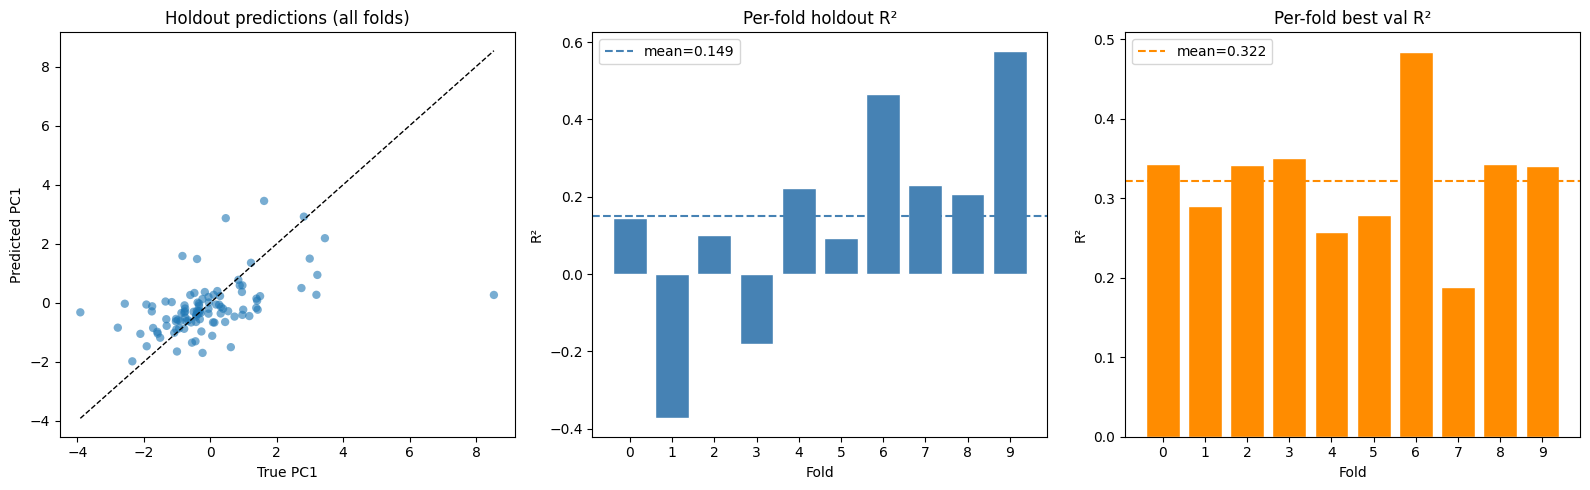

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Scatter: pooled predictions vs true
ax = axes[0]
ax.scatter(results_df["true_pc1"], results_df["pred_pc1"], alpha=0.6, edgecolors="none")
lims = [results_df[["true_pc1", "pred_pc1"]].min().min(),
        results_df[["true_pc1", "pred_pc1"]].max().max()]
ax.plot(lims, lims, "k--", lw=1)
ax.set(xlabel="True PC1", ylabel="Predicted PC1", title="Holdout predictions (all folds)")

# Bar: per-fold holdout R²
ax = axes[1]
ax.bar(range(N_FOLDS), fold_r2_arr, color="steelblue", edgecolor="white")
ax.axhline(fold_r2_arr.mean(), color="steelblue", linestyle="--",
           label=f"mean={fold_r2_arr.mean():.3f}")
ax.set(xlabel="Fold", ylabel="R²", title="Per-fold holdout R²", xticks=range(N_FOLDS))
ax.legend()

# Bar: best val R² per fold
ax = axes[2]
ax.bar(range(N_FOLDS), best_val_r2_arr, color="darkorange", edgecolor="white")
ax.axhline(best_val_r2_arr.mean(), color="darkorange", linestyle="--",
           label=f"mean={best_val_r2_arr.mean():.3f}")
ax.set(xlabel="Fold", ylabel="R²", title="Per-fold best val R²", xticks=range(N_FOLDS))
ax.legend()

plt.tight_layout()
plt.savefig("model_data/cv_results/cv_summary.png", dpi=150)
plt.show()